# Regression using Keras

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
pd.set_option('display.max_columns', None)

In [2]:
from tensorflow import keras

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### Import Dataset from Keras Datasets
Check https://www.tensorflow.org/api_docs/python/tf/keras/datasets

or https://keras.io/datasets/

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.boston_housing.load_data()

In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((404, 13), (404,), (102, 13), (102,))

In [5]:
model = keras.models.Sequential()
model.add(keras.layers.Input((13,)))
model.add(keras.layers.Dense(10))
model.add(keras.layers.Dense(1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(loss='mse', metrics=['mae'])

In [7]:
model.fit(X_train, y_train, epochs=500, validation_data=(X_test, y_test))

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8762.1250 - mae: 87.0248 - val_loss: 3284.0432 - val_mae: 53.7243
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1626.8318 - mae: 35.2587 - val_loss: 838.4973 - val_mae: 23.8468
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 614.3348 - mae: 20.4424 - val_loss: 522.0897 - val_mae: 18.1631
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 435.4211 - mae: 17.2442 - val_loss: 404.9613 - val_mae: 15.8885
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 298.3054 - mae: 14.2543 - val_loss: 286.0356 - val_mae: 13.4597
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 224.2729 - mae: 12.2584 - val_loss: 284.8053 - val_mae: 13.0404
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 198.8504 - mae: 11.3042 - val_loss: 281.0540 - val_mae: 12.7820
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 172.7677 - mae: 10.4956 - val_loss: 189.1127 - val_mae: 11.1765
Epoch 9/500


In [8]:
pred = model.predict(X_test)
pred[4], y_test[4]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


(array([25.626238], dtype=float32), np.float64(22.2))

<Axes: >

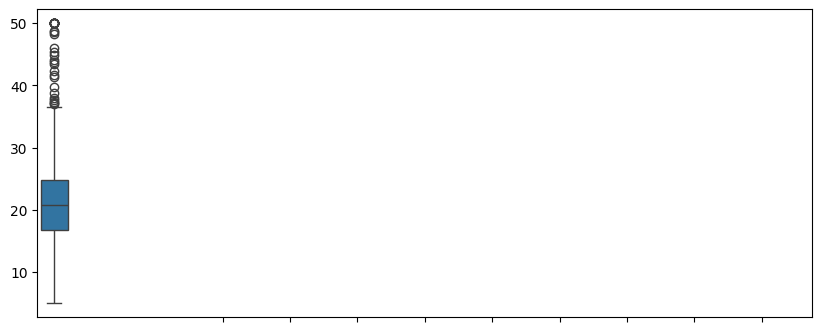

In [9]:
plt.figure(figsize=(10,4))
plt.xticks(np.arange(min(y_train), max(y_train)+1, 2.0))
sns.boxplot(y_train)

### Try Scaling features first

In [10]:
from sklearn.preprocessing import MinMaxScaler

In [11]:
x_scaler = MinMaxScaler()
x_scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [12]:
y_scaler = MinMaxScaler()
y_scaler.fit([y_train])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [13]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Input((13,)))
model2.add(keras.layers.Dense(10))
model2.add(keras.layers.Dense(1))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
model2.compile(loss='mse', metrics=['mae'])

In [15]:
model2.fit(x_scaler.transform(X_train), y_train, epochs=500, validation_data=(x_scaler.transform(X_test), y_test))

Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 525.1780 - mae: 20.8421 - val_loss: 541.9588 - val_mae: 21.2397
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 507.0390 - mae: 20.3876 - val_loss: 525.4475 - val_mae: 20.8237
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 491.5125 - mae: 19.9777 - val_loss: 509.5531 - val_mae: 20.4139
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 476.2115 - mae: 19.5646 - val_loss: 493.5036 - val_mae: 19.9909
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 460.4942 - mae: 19.1407 - val_loss: 476.9558 - val_mae: 19.5428
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 444.4191 - mae: 18.6940 - val_loss: 460.0392 - val_mae: 19.0807
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 428.1626 - mae: 18.2263 - val_loss: 442.9987 - val_mae: 18.6077
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 411.6373 - mae: 17.7498 - val_loss: 425.8846 - val_mae: 18.1206
Epoch 9/5

### Visualize Predictions

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


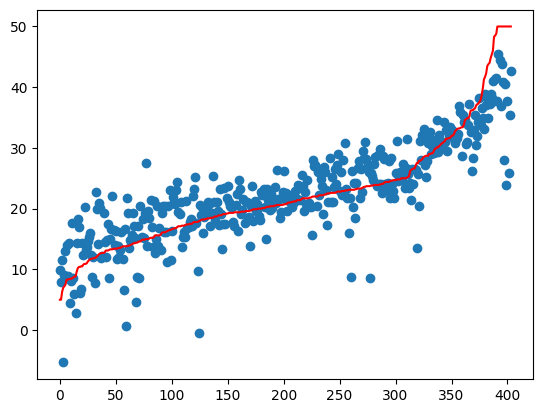

In [16]:
indices = np.argsort(y_train)
sorted_y_train = y_train[indices]
sorted_x_train = X_train[indices]
r = list(range(len(sorted_y_train)))
plt.scatter(r, model2.predict(x_scaler.transform(sorted_x_train)).reshape(-1))
plt.plot(r, sorted_y_train, 'r')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


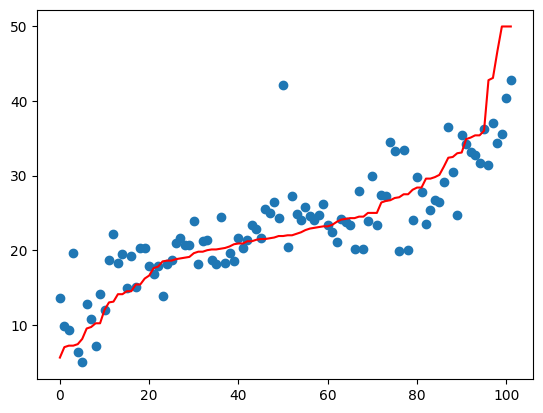

In [17]:
indices = np.argsort(y_test)
sorted_y_test = y_test[indices]
sorted_x_test = X_test[indices]
r = list(range(len(sorted_y_test)))
plt.scatter(r, model2.predict(x_scaler.transform(sorted_x_test)).reshape(-1))
plt.plot(r, sorted_y_test, 'r')

## Save & Load models

### Save

In [18]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 304 (1.19 KB)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 153 (616.00 B)

In [19]:
model2.save("model2.h5")

In [20]:
model2.weights

[<Variable path=sequential_1/dense_2/kernel, shape=(13, 10), dtype=float32, value=[[-0.8589007  -0.54713285  0.83827585  0.79246706 -0.28959647  0.7109319
    0.7248942   0.71063995 -0.02432982  0.30703157]
  [ 0.24800625 -0.0084682  -0.2876411  -0.6554103   0.3152136  -0.36552224
   -0.51548696 -0.5026563  -0.25598258 -0.36829805]
  [-0.10158866  0.26015463  0.01628258  0.35685834 -0.31992722 -0.1238103
    0.11234782 -0.22070254 -0.4418284   0.20969628]
  [-0.13037051  0.2675678  -0.7968198  -0.6661559   0.05790289 -0.28943753
    0.04758497 -0.62316734 -0.37307277  0.01299253]
  [-0.90792656 -0.04082699 -0.04304273  0.92450243 -0.15519105  0.16069852
    0.39247632  0.6220687   0.10601871  0.31938747]
  [ 1.7259215   1.1809915  -1.9010876  -2.026219    1.7309196  -1.0754118
   -1.9629426  -1.2979525  -1.5967178  -1.5052977 ]
  [-0.06230165  0.3635867   0.0102783  -0.35379273  0.08156455 -0.45233786
   -0.39422202  0.18871482 -0.13473931 -0.05497403]
  [-0.83816487 -1.1298181   0.476

In [21]:
model2.save_weights('weights2.weights.h5')

### Load

In [22]:
model3 = keras.models.load_model('model2.h5', compile=False)
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 10)                  │             140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model3.weights

[<Variable path=sequential_1/dense_2/kernel, shape=(13, 10), dtype=float32, value=[[-0.8589007  -0.54713285  0.83827585  0.79246706 -0.28959647  0.7109319
    0.7248942   0.71063995 -0.02432982  0.30703157]
  [ 0.24800625 -0.0084682  -0.2876411  -0.6554103   0.3152136  -0.36552224
   -0.51548696 -0.5026563  -0.25598258 -0.36829805]
  [-0.10158866  0.26015463  0.01628258  0.35685834 -0.31992722 -0.1238103
    0.11234782 -0.22070254 -0.4418284   0.20969628]
  [-0.13037051  0.2675678  -0.7968198  -0.6661559   0.05790289 -0.28943753
    0.04758497 -0.62316734 -0.37307277  0.01299253]
  [-0.90792656 -0.04082699 -0.04304273  0.92450243 -0.15519105  0.16069852
    0.39247632  0.6220687   0.10601871  0.31938747]
  [ 1.7259215   1.1809915  -1.9010876  -2.026219    1.7309196  -1.0754118
   -1.9629426  -1.2979525  -1.5967178  -1.5052977 ]
  [-0.06230165  0.3635867   0.0102783  -0.35379273  0.08156455 -0.45233786
   -0.39422202  0.18871482 -0.13473931 -0.05497403]
  [-0.83816487 -1.1298181   0.476

#### Load Weights only

In [24]:
model4 = keras.models.Sequential()
model4.add(keras.layers.Input((13,)))
model4.add(keras.layers.Dense(10))
model4.add(keras.layers.Dense(1))

In [25]:
model4.weights

[<Variable path=sequential_2/dense_4/kernel, shape=(13, 10), dtype=float32, value=[[ 0.449194    0.4310677  -0.13002068  0.38247192  0.3610245  -0.14584973
   -0.03251407 -0.4182378  -0.09491467  0.17839873]
  [ 0.23727721 -0.26824644 -0.32986516 -0.2570662   0.39788175  0.37463462
   -0.270273    0.06254613  0.33253688  0.04278225]
  [ 0.02097166 -0.21826646 -0.12263489 -0.3265824   0.06097198 -0.16515955
   -0.48146296  0.234644   -0.12961507 -0.1140137 ]
  [-0.32808352  0.18735188 -0.3614077   0.08606201 -0.11057374 -0.42086178
   -0.49897748 -0.42488238  0.2981118   0.4674415 ]
  [ 0.33410275  0.4720409  -0.29500598 -0.19833949  0.30715406  0.02212155
    0.5080361  -0.11553538 -0.2831253   0.47560787]
  [-0.4976046   0.00543606  0.3985873  -0.18947574  0.18465376 -0.30580106
    0.5049847  -0.18629855  0.49419254  0.41092497]
  [-0.4427337   0.10299397 -0.00263751  0.30503976  0.38273144 -0.07727328
   -0.24835417  0.06096298  0.5013636  -0.13863662]
  [-0.11957011 -0.13147211 -0.

In [26]:
model4.load_weights('weights2.weights.h5')

In [27]:
model4.weights

[<Variable path=sequential_2/dense_4/kernel, shape=(13, 10), dtype=float32, value=[[-0.8589007  -0.54713285  0.83827585  0.79246706 -0.28959647  0.7109319
    0.7248942   0.71063995 -0.02432982  0.30703157]
  [ 0.24800625 -0.0084682  -0.2876411  -0.6554103   0.3152136  -0.36552224
   -0.51548696 -0.5026563  -0.25598258 -0.36829805]
  [-0.10158866  0.26015463  0.01628258  0.35685834 -0.31992722 -0.1238103
    0.11234782 -0.22070254 -0.4418284   0.20969628]
  [-0.13037051  0.2675678  -0.7968198  -0.6661559   0.05790289 -0.28943753
    0.04758497 -0.62316734 -0.37307277  0.01299253]
  [-0.90792656 -0.04082699 -0.04304273  0.92450243 -0.15519105  0.16069852
    0.39247632  0.6220687   0.10601871  0.31938747]
  [ 1.7259215   1.1809915  -1.9010876  -2.026219    1.7309196  -1.0754118
   -1.9629426  -1.2979525  -1.5967178  -1.5052977 ]
  [-0.06230165  0.3635867   0.0102783  -0.35379273  0.08156455 -0.45233786
   -0.39422202  0.18871482 -0.13473931 -0.05497403]
  [-0.83816487 -1.1298181   0.476